<a href="https://colab.research.google.com/github/eswardn12/Data-Science-60-Day-Portfolio/blob/main/Day2_Customer_Segmentation_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2 — Customer Segmentation & Profiling: Hands-On Notebook


This notebook extends Day 1's lighter K-Means exercise into genuine segmentation depth:

1. **(Deep) Hierarchical Clustering** — Ward linkage, dendrogram-driven segment selection, vs. K-Means baseline
2. **(Deep) Gaussian Mixture Models** — soft/probabilistic segments, BIC-based model selection, ambiguous-buyer analysis
3. **(Lighter) Segment-to-Strategy Translation** — turning any clustering output into a business-ready brief

Plus **Named Extensions** for further independent practice.

All data is synthetic, built from underlying buyer archetypes unknown to the algorithms — a good way to sanity-check whether each method recovers sensible structure.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

np.random.seed(7)
plt.rcParams['figure.figsize'] = (10, 5)
EBAY_BLUE = '#0064D2'; EBAY_RED = '#E53238'; EBAY_GOLD = '#F5AF02'; EBAY_GREEN = '#86B817'
print('Environment ready.')


Environment ready.


---
## Shared Dataset — Synthetic Buyer Behavior with Known Archetypes
We generate buyers from five underlying archetypes (VIP, Loyal-Value, New, At-Risk, Occasional) across four features: recency, frequency, monetary value, and an engagement score. The archetype label is hidden from every algorithm below — we only reveal it afterward, as a sanity check on whether the unsupervised methods recover sensible structure.


In [2]:
n = 3000
archetypes = np.random.choice(['vip', 'loyal_value', 'new', 'at_risk', 'occasional'],
                               size=n, p=[0.10, 0.25, 0.20, 0.20, 0.25])
params = {
    'vip':          dict(rec=(3, 5),    freq=(18, 3), mon=(4, 90),  eng=(40, 8)),
    'loyal_value':  dict(rec=(10, 8),   freq=(9, 2),  mon=(2.5, 55),eng=(20, 6)),
    'new':          dict(rec=(5, 6),    freq=(1, 1),  mon=(1.5, 40),eng=(15, 5)),
    'at_risk':      dict(rec=(120, 40), freq=(2, 1),  mon=(1.8, 45),eng=(5, 3)),
    'occasional':   dict(rec=(45, 20),  freq=(3, 1),  mon=(1.2, 30),eng=(8, 3)),
}
rows = []
for a in archetypes:
    p = params[a]
    rec = np.clip(np.random.exponential(p['rec'][0]) + np.random.normal(0, p['rec'][1]), 0, 365)
    freq = np.clip(np.random.poisson(p['freq'][0]), 0, 60)
    mon = np.random.gamma(p['mon'][0], p['mon'][1])
    eng = np.clip(np.random.poisson(p['eng'][0]) + np.random.normal(0, p['eng'][1]), 0, 100)
    rows.append([rec, freq, mon, eng, a])

df = pd.DataFrame(rows, columns=['recency_days', 'frequency_orders', 'monetary_value', 'engagement_score', 'true_archetype'])
print(f'Shape: {df.shape}')
df.groupby('true_archetype').mean(numeric_only=True).round(1)


Shape: (3000, 5)


,recency_days,frequency_orders,monetary_value,engagement_score
true_archetype,,,,
at_risk,116.9,2.0,82.4,5.2
loyal_value,11.1,8.9,135.2,19.9
new,6.0,1.0,62.7,14.7
occasional,45.2,3.0,36.6,7.8
vip,4.5,18.1,371.0,39.6


In [3]:
features = ['recency_days', 'frequency_orders', 'monetary_value', 'engagement_score']
scaler = StandardScaler()
X = scaler.fit_transform(df[features])
print('Features scaled. Mean ~0, Std ~1 per feature:')
pd.DataFrame(X, columns=features).describe().round(2).loc[['mean','std']]


Features scaled. Mean ~0, Std ~1 per feature:


,recency_days,frequency_orders,monetary_value,engagement_score
mean,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0


---
## Case Study 1 (Deep) — Hierarchical Clustering with Dendrogram-Driven Segment Selection
**Business framing:** Rather than pre-committing to a K, we let Ward-linkage agglomerative clustering reveal the natural grouping structure, then compare the resulting segments against a K-Means baseline on the same data (Day 1 report Section 6, extended in Day 2 Section 4).


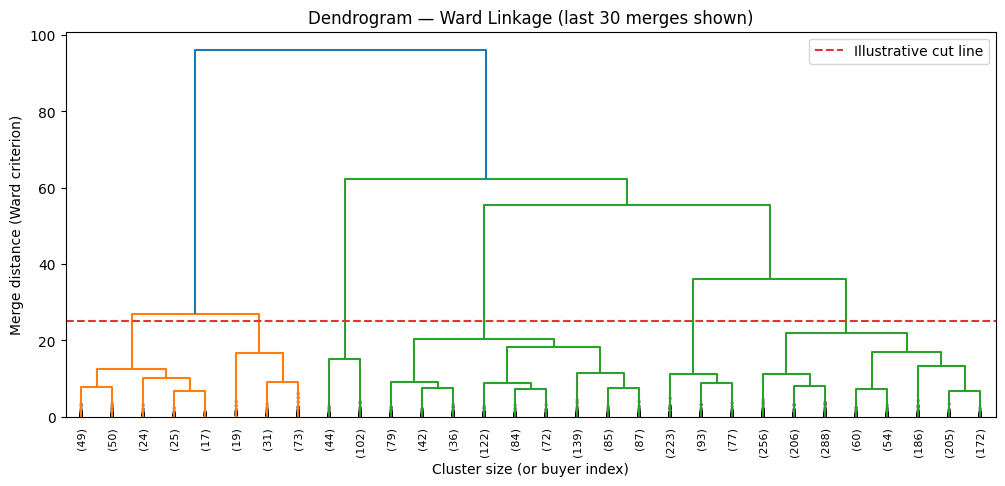

In [4]:
# 1.1 Build the linkage matrix (Ward's method)
Z = linkage(X, method='ward')

# 1.2 Plot dendrogram (truncated for readability at this scale)
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=8., show_contracted=True)
plt.title('Dendrogram — Ward Linkage (last 30 merges shown)')
plt.xlabel('Cluster size (or buyer index)'); plt.ylabel('Merge distance (Ward criterion)')
plt.axhline(y=25, color=EBAY_RED, linestyle='--', label='Illustrative cut line')
plt.legend(); plt.show()


In [5]:
# 1.3 Silhouette score across candidate K values (cutting the dendrogram at different heights)
sil_scores = {}
for k in range(2, 8):
    labels = fcluster(Z, t=k, criterion='maxclust')
    sil_scores[k] = silhouette_score(X, labels)
    print(f'K={k}: silhouette={sil_scores[k]:.4f}')

best_k_hier = max(sil_scores, key=sil_scores.get)
print(f'\nBest K by silhouette: {best_k_hier}')


K=2: silhouette=0.5656
K=3: silhouette=0.5155
K=4: silhouette=0.3609
K=5: silhouette=0.3263
K=6: silhouette=0.3200
K=7: silhouette=0.2346

Best K by silhouette: 2


In [6]:
# 1.4 Compare Hierarchical (best K) against K-Means baseline at the same K
hier_labels = fcluster(Z, t=best_k_hier, criterion='maxclust')
km = KMeans(n_clusters=best_k_hier, n_init=10, random_state=42).fit(X)

print(f'Hierarchical (Ward), K={best_k_hier}: silhouette={silhouette_score(X, hier_labels):.4f}')
print(f'K-Means,            K={best_k_hier}: silhouette={silhouette_score(X, km.labels_):.4f}')

df['hier_segment'] = hier_labels
df.groupby('hier_segment')[features].mean().round(1)


Hierarchical (Ward), K=2: silhouette=0.5656
K-Means,            K=2: silhouette=0.4980


,recency_days,frequency_orders,monetary_value,engagement_score
hier_segment,,,,
1,4.7,18.2,374.2,40.6
2,41.6,4.1,82.1,12.4


In [7]:
# 1.5 Sanity check: does the recovered structure line up with the hidden true archetypes?
pd.crosstab(df['true_archetype'], df['hier_segment'])


hier_segment,1,2
true_archetype,,
at_risk,0,577
loyal_value,5,778
new,0,604
occasional,0,733
vip,283,20


**Reading the crosstab:** A clean-ish diagonal-ish pattern (most of each true archetype falling predominantly into one segment) indicates the algorithm recovered structure close to the underlying generative process — a useful sanity check available here only because this is synthetic data with a known ground truth. On real eBay/Walmart data you will never have this crosstab, which is exactly why the business-translation discipline from the Day 2 report (Section 7.2) matters so much: it is your substitute for a ground-truth check you'll never actually have.


---
## Case Study 2 (Deep) — Gaussian Mixture Models for Soft Buyer Segmentation
**Business framing:** Identifying buyers who sit ambiguously between two segments — a group hard-clustering methods hide entirely, but which is highly actionable for CRM teams deciding which of two treatments to test on a borderline buyer.


K=2: BIC=21809.1
K=3: BIC=20079.3
K=4: BIC=19131.5
K=5: BIC=18069.9
K=6: BIC=15535.4
K=7: BIC=15403.1
K=8: BIC=15305.7


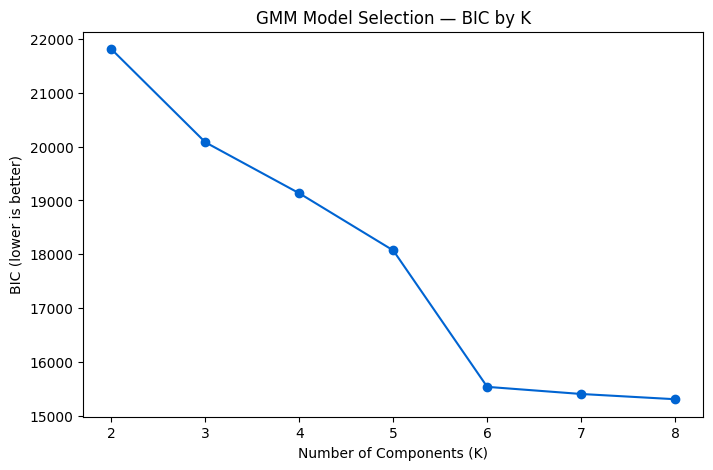

In [8]:
# 2.1 Fit GMM across a range of component counts, track BIC
bics = {}
for k in range(2, 9):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=3).fit(X)
    bics[k] = gmm.bic(X)
    print(f'K={k}: BIC={bics[k]:.1f}')

plt.figure(figsize=(8,5))
plt.plot(list(bics.keys()), list(bics.values()), marker='o', color=EBAY_BLUE)
plt.xlabel('Number of Components (K)'); plt.ylabel('BIC (lower is better)')
plt.title('GMM Model Selection — BIC by K')
plt.show()


In [9]:
# 2.2 Elbow-based selection: the point past which further BIC improvement flattens out,
# rather than blindly taking the raw minimum (Day 2 report Section 5.3 / 7.1 caveat)
ks = sorted(bics.keys())
diffs = {ks[i]: bics[ks[i]] - bics[ks[i+1]] for i in range(len(ks)-1)}
max_diff = max(diffs.values())
elbow_k = ks[-1]
for k in ks[:-1]:
    if diffs[k] < 0.2 * max_diff:
        elbow_k = k
        break
print('Raw BIC-minimizing K:', min(bics, key=bics.get))
print('Elbow-selected K (business-usable):', elbow_k)


Raw BIC-minimizing K: 8
Elbow-selected K (business-usable): 6


In [11]:
# 2.3 Fit final GMM at the elbow-selected K and extract soft membership
gmm_final = GaussianMixture(n_components=elbow_k, random_state=42, n_init=5).fit(X)
probs = gmm_final.predict_proba(X)
df['gmm_segment'] = probs.argmax(axis=1)
df['gmm_max_prob'] = probs.max(axis=1)

ambiguous_pct = (df['gmm_max_prob'] < 0.6).mean()
print(f'Segments (K={elbow_k}): ambiguous buyers (max posterior < 0.6): {ambiguous_pct:.1%}')
df.groupby('gmm_segment')[features + ['gmm_max_prob']].mean().round(2)


Segments (K=6): ambiguous buyers (max posterior < 0.6): 4.7%


,recency_days,frequency_orders,monetary_value,engagement_score,gmm_max_prob
gmm_segment,,,,,
0,51.99,2.85,31.21,7.29,0.87
1,0.00,5.08,100.18,15.95,0.96
2,165.82,2.21,100.31,5.17,0.92
3,5.22,17.86,386.94,38.93,0.95
4,7.42,1.03,50.97,13.26,0.88
5,13.80,8.30,130.91,19.44,0.94


In [12]:
# 2.4 Look specifically at the ambiguous buyers — the group hard clustering hides
ambiguous = df[df['gmm_max_prob'] < 0.6]
print(f'{len(ambiguous)} buyers ({len(ambiguous)/len(df):.1%}) sit ambiguously between segments.')
ambiguous[features + ['true_archetype', 'gmm_segment', 'gmm_max_prob']].sample(8, random_state=1)


141 buyers (4.7%) sit ambiguously between segments.


,recency_days,frequency_orders,monetary_value,engagement_score,true_archetype,gmm_segment,gmm_max_prob
1803,118.076053,0,59.579933,3.422913,at_risk,2,0.551916
2507,4.608830,14,237.685044,22.409208,loyal_value,5,0.500599
701,140.436595,3,39.576178,9.600777,occasional,2,0.572486
78,42.645043,9,16.702416,13.539305,loyal_value,5,0.507687
2713,0.577601,3,99.908613,0.000000,new,2,0.426387
998,15.303367,3,143.659870,6.949216,at_risk,5,0.574234
275,0.240623,11,314.222656,17.519406,loyal_value,5,0.360938
971,4.746416,5,74.253802,2.778127,occasional,0,0.468312


**CRM implication:** These ambiguous buyers are natural candidates for a lightweight A/B test — e.g., testing which of two nearby segments' treatments (a loyalty perk vs. a win-back nudge) performs better on this exact population, rather than guessing. GMM makes this population visible; K-Means or Hierarchical clustering would have silently forced each of them into one arbitrary bucket.


---
## Case Study 3 (Lighter) — Segment-to-Strategy Translation
**Business framing:** Operationalizing Day 2 report Section 8.1's segment brief template — turning any clustering output into the one-pager a category manager could act on tomorrow morning.


In [13]:
# 3.1 A reusable profiling + naming function
def build_segment_brief(data, segment_col, features):
    profile = data.groupby(segment_col)[features].mean().round(1)
    profile['size'] = data.groupby(segment_col).size()
    profile['pct_of_base'] = (profile['size'] / len(data) * 100).round(1)

    # simple rule-based naming heuristic based on relative feature ranks
    names = []
    for idx, row in profile.iterrows():
        if row['monetary_value'] >= profile['monetary_value'].quantile(0.75) and row['recency_days'] <= profile['recency_days'].quantile(0.35):
            names.append('VIP / Protect')
        elif row['recency_days'] >= profile['recency_days'].quantile(0.65):
            names.append('At-Risk / Win-Back')
        elif row['frequency_orders'] <= profile['frequency_orders'].quantile(0.35) and row['engagement_score'] >= profile['engagement_score'].median():
            names.append('New & Exploring / Nurture')
        else:
            names.append('Steady / Broad Campaigns')
    profile['business_name'] = names
    return profile.sort_values('pct_of_base', ascending=False)

brief_hier = build_segment_brief(df, 'hier_segment', features)
brief_hier


,recency_days,frequency_orders,monetary_value,engagement_score,size,pct_of_base,business_name
hier_segment,,,,,,,
2,41.6,4.1,82.1,12.4,2712,90.4,At-Risk / Win-Back
1,4.7,18.2,374.2,40.6,288,9.6,VIP / Protect


In [14]:
# 3.2 Same translation applied to the GMM output, for comparison
brief_gmm = build_segment_brief(df, 'gmm_segment', features)
brief_gmm


,recency_days,frequency_orders,monetary_value,engagement_score,size,pct_of_base,business_name
gmm_segment,,,,,,,
5,13.8,8.3,130.9,19.4,690,23.0,Steady / Broad Campaigns
0,52.0,2.8,31.2,7.3,663,22.1,At-Risk / Win-Back
1,0.0,5.1,100.2,15.9,516,17.2,Steady / Broad Campaigns
4,7.4,1.0,51.0,13.3,467,15.6,Steady / Broad Campaigns
2,165.8,2.2,100.3,5.2,394,13.1,At-Risk / Win-Back
3,5.2,17.9,386.9,38.9,270,9.0,VIP / Protect


**Note:** This naming heuristic is intentionally simple (quantile-based rules) to keep the translation step transparent and auditable — in production, category managers typically refine these names manually after reviewing the statistical profile, but having an automated first draft (as done here) removes the blank-page problem every single refresh cycle.


---
## Named Extensions (Scoped, Not Fully Built)

1. **DBSCAN/HDBSCAN** on the same feature space — explicitly surface outlier buyers that K-Means/GMM/Hierarchical are forced to assign to a segment
2. **PCA-based 2D visualization** comparing how K-Means, Hierarchical, and GMM partition the same reduced feature space visually
3. **LLM-generated persona paragraphs** — draft a short natural-language persona brief per segment, grounded strictly in that segment's summary statistics from `build_segment_brief` above (a lightweight, ungrounded-hallucination-safe RAG-style exercise)

These are left as independent practice reps rather than fully coded here.


---
## Summary — What This Notebook Proves You Can Do
- Run agglomerative hierarchical clustering end-to-end, including dendrogram interpretation and a defensible K-selection process
- Fit and interpret Gaussian Mixture Models, including a business-aware (not just statistically pure) approach to choosing the number of components
- Surface and reason about ambiguous, boundary-case buyers that hard-clustering methods hide
- Convert any clustering output into a standardized, business-ready segment brief — the deliverable that actually gets used in a business review

**Next:** Day 3 — Lead Scoring & Response Propensity Modeling, applying supervised classification and calibration on top of today's segments.
